# Transition Frequency Baseline Analysis

In [1]:
import os
os.chdir("../")

from dotenv import load_dotenv
load_dotenv()
os.environ["WANDB_API_KEY"] = os.getenv("WANDB_API_KEY")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ppm.wandb_utils import fetch_baseline_tables, load_multiple_experiments, BASELINE_PROJECT
from visualization.visualization import alias, _apply_style

LIFECYCLE = {
    "BPI12": True,
    "BPI15": True,
    "BPI17": True,
    "BPI19": True,
    # other datasets do not support lifecycle
}

## All Datasets Overview

In [2]:
%%capture
baseline_runs, _ = load_multiple_experiments([BASELINE_PROJECT], force_update=False)
if "lifecycle" not in baseline_runs.columns:
    baseline_runs["lifecycle"] = False
baseline_runs["lifecycle"] = baseline_runs["lifecycle"].fillna(False).astype(bool)
baseline_latest = baseline_runs[
    baseline_runs.apply(lambda r: LIFECYCLE.get(r["log"], False) == r["lifecycle"], axis=1)
].sort_values("created_at", ascending=False).drop_duplicates("log", keep="first")
baseline_latest = baseline_latest.sort_values("log")
baseline_latest["log_alias"] = baseline_latest["log"].apply(alias)


## Baseline Performance by Dataset

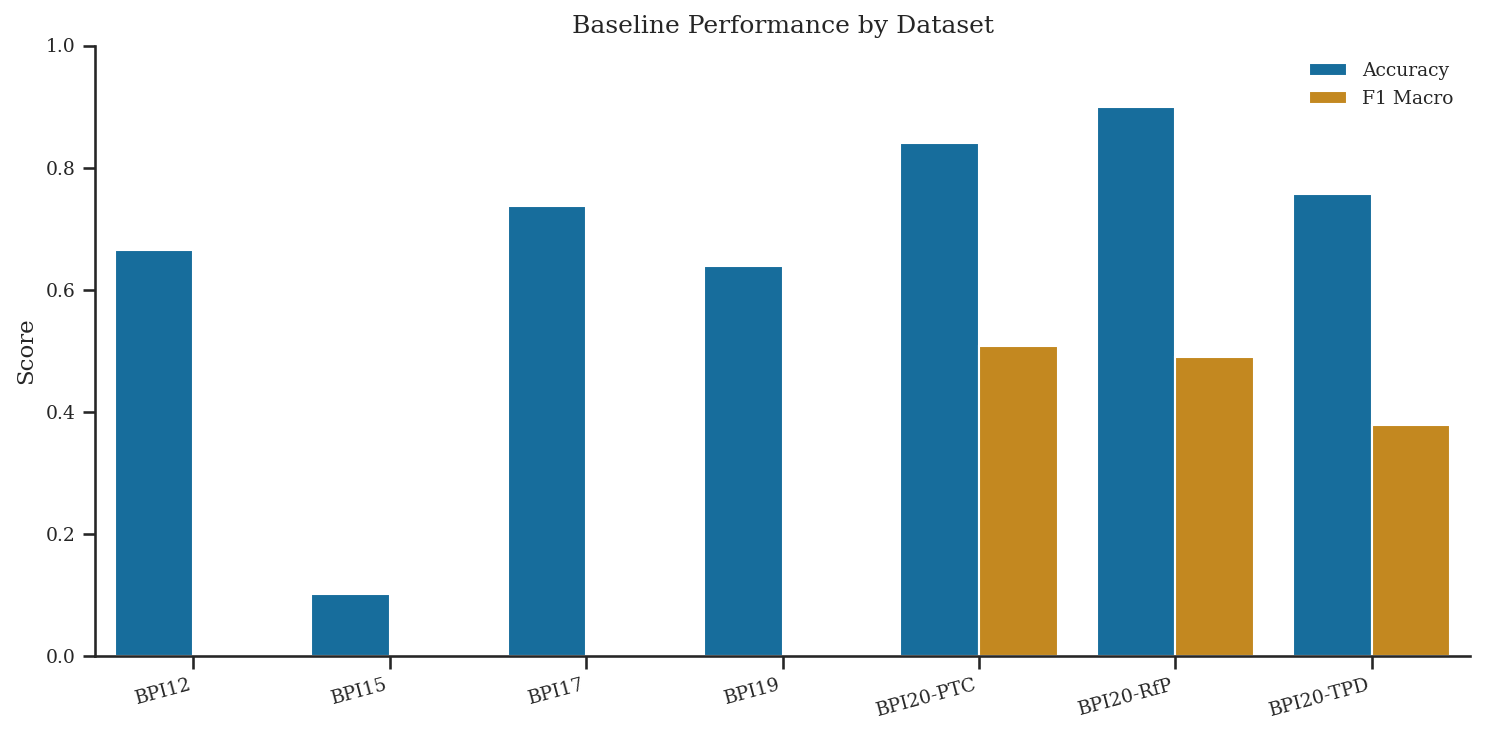

,Dataset,Accuracy,F1 Macro
0,BPI12,0.665328,NaN
1,BPI15,0.101830,NaN
2,BPI17,0.737479,NaN
3,BPI19,0.638558,NaN
4,BPI20-PTC,0.840435,0.507489
5,BPI20-RfP,0.899694,0.490485
6,BPI20-TPD,0.756941,0.378038


In [3]:
_apply_style()

plot_df = baseline_latest[["log", "best_test_final_next_activity_acc", "best_test_final_next_activity_f1_macro"]].copy()
plot_df["Dataset"] = plot_df["log"].apply(alias)
plot_df = plot_df.melt(id_vars=["Dataset"], value_vars=["best_test_final_next_activity_acc", "best_test_final_next_activity_f1_macro"], var_name="Metric", value_name="Score")
plot_df["Metric"] = plot_df["Metric"].map({"best_test_final_next_activity_acc": "Accuracy", "best_test_final_next_activity_f1_macro": "F1 Macro"})

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=plot_df, x="Dataset", y="Score", hue="Metric", ax=ax, palette="colorblind")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_ylim(0, 1)
ax.set_title("Baseline Performance by Dataset")
ax.legend(frameon=False)
ax.tick_params(axis="x", rotation=15)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
fig.tight_layout()
plt.show()
display(baseline_latest[["log_alias", "best_test_final_next_activity_acc", "best_test_final_next_activity_f1_macro"]].rename(
    columns={"log_alias": "Dataset", "best_test_final_next_activity_acc": "Accuracy", "best_test_final_next_activity_f1_macro": "F1 Macro"}
).reset_index(drop=True))

### Complexity Metrics Comparison

In [4]:
all_datasets = baseline_latest["log"].tolist()

complexity_data = []
for ds in all_datasets:
    trans_df, _ = fetch_baseline_tables(ds, lifecycle=LIFECYCLE.get(ds, False))
    branching = len(trans_df) / trans_df["current_activity"].nunique()
    complexity_data.append({
        "Dataset": alias(ds),
        "log": ds,
        "Branching Factor": branching,
        "Unique Transitions": len(trans_df),
        "Total Transitions": trans_df["count"].sum(),
    })

complexity_df = pd.DataFrame(complexity_data)

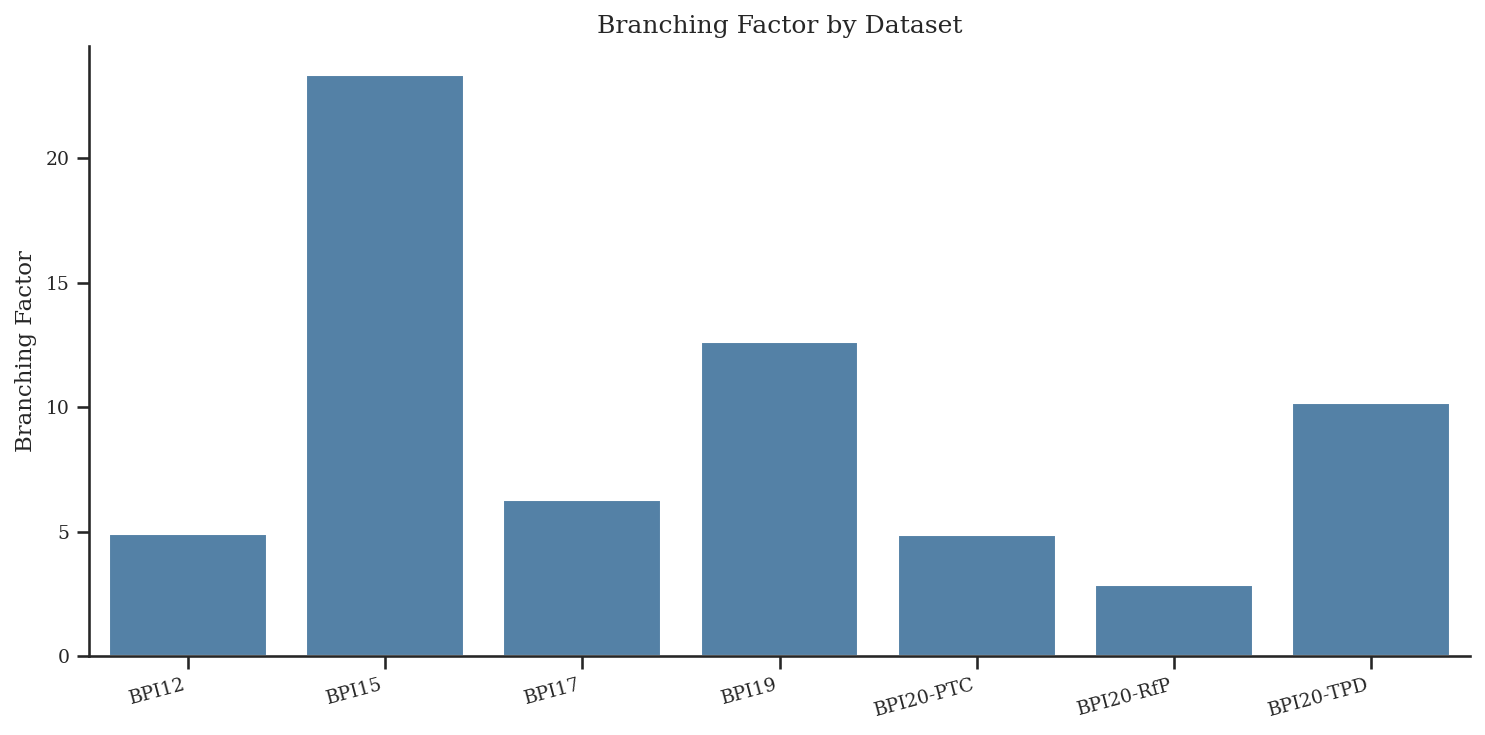

,Dataset,log,Branching Factor,Unique Transitions,Total Transitions
0,BPI12,BPI12,4.916667,177,130644
1,BPI15,BPI15,23.370968,7245,157278
2,BPI17,BPI17,6.278689,383,856343
3,BPI19,BPI19,12.625000,505,590378
4,BPI20-PTC,BPI20PrepaidTravelCosts,4.857143,136,11047
5,BPI20-RfP,BPI20RequestForPayment,2.857143,40,19469
6,BPI20-TPD,BPI20TravelPermitData,10.160000,508,60964


In [5]:
_apply_style()

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(data=complexity_df, x="Dataset", y="Branching Factor", ax=ax, color="steelblue")
ax.set_title("Branching Factor by Dataset")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=15)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

fig.tight_layout()
plt.show()
complexity_df

### Transition Statistics Comparison

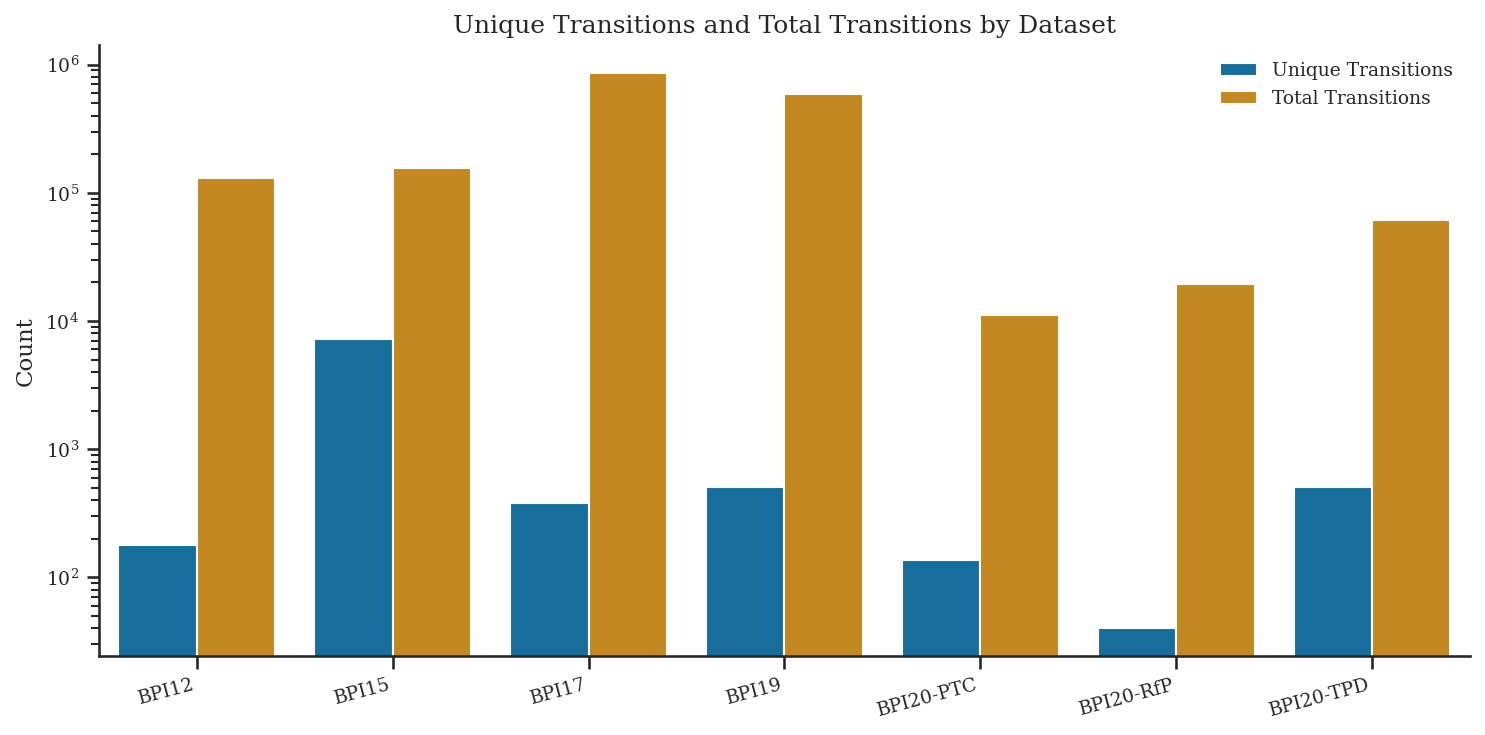

In [6]:
_apply_style()

stats_df = complexity_df[["Dataset", "Unique Transitions", "Total Transitions"]].melt(
    id_vars=["Dataset"], var_name="Metric", value_name="Count"
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=stats_df, x="Dataset", y="Count", hue="Metric", ax=ax, palette="colorblind")
ax.set_ylabel("Count")
ax.set_xlabel("")
ax.set_yscale("log")
ax.set_title("Unique Transitions and Total Transitions by Dataset")
ax.legend(frameon=False)
ax.tick_params(axis="x", rotation=15)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
fig.tight_layout()
plt.show()

### Self-Transition Comparison

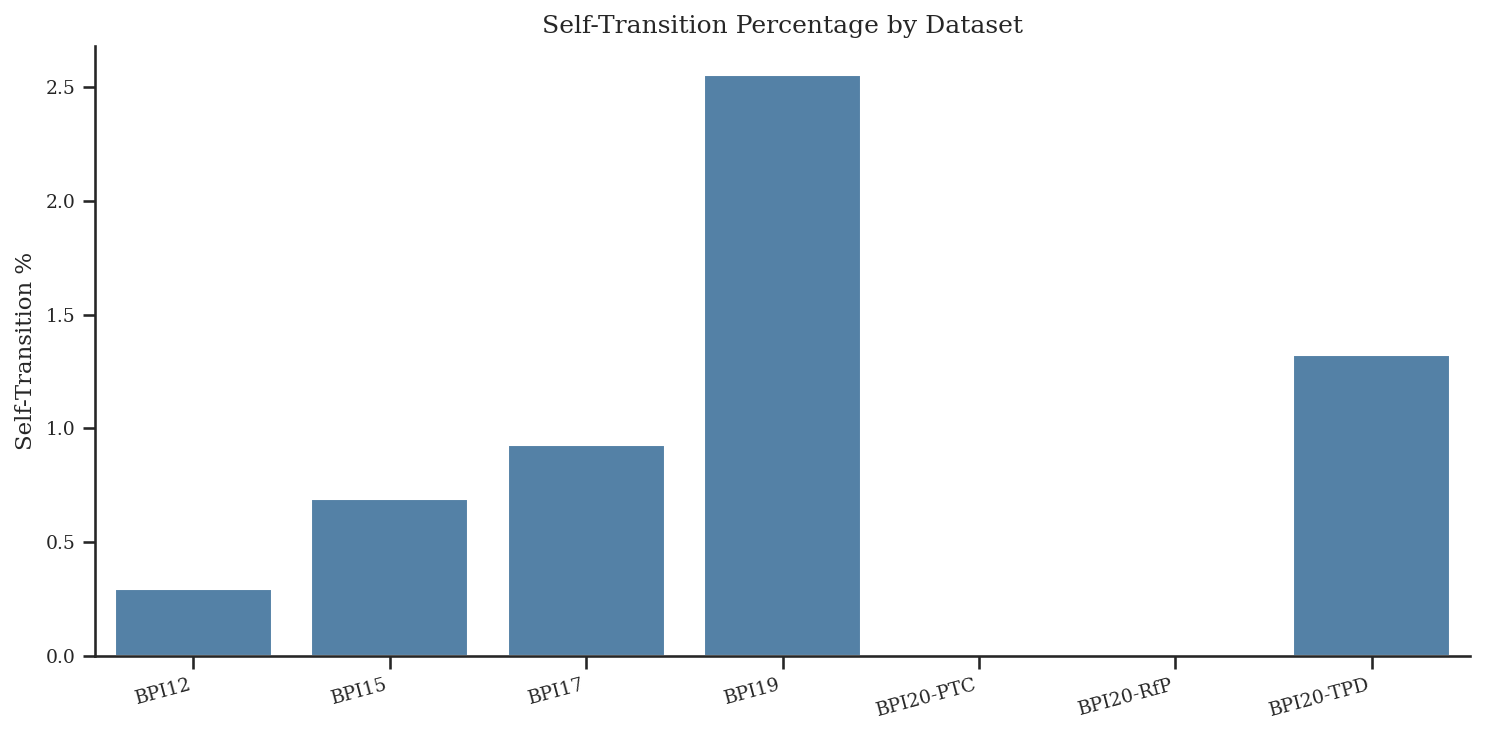

,Dataset,Self-Transition %
0,BPI12,0.293163
1,BPI15,0.690497
2,BPI17,0.924746
3,BPI19,2.553788
4,BPI20-PTC,0.000000
5,BPI20-RfP,0.000000
6,BPI20-TPD,1.320451


In [7]:
_apply_style()

self_trans_data = []
for ds in all_datasets:
    trans_df, _ = fetch_baseline_tables(ds, lifecycle=LIFECYCLE.get(ds, False))
    self_trans = trans_df[trans_df["current_activity"] == trans_df["next_activity"]]
    self_count = self_trans["count"].sum()
    total_count = trans_df["count"].sum()
    self_trans_data.append({
        "Dataset": alias(ds),
        "Self-Transition %": (self_count / total_count) * 100
    })

self_trans_df = pd.DataFrame(self_trans_data)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=self_trans_df, x="Dataset", y="Self-Transition %", ax=ax, color="steelblue")
ax.set_ylabel("Self-Transition %")
ax.set_xlabel("")
ax.set_title("Self-Transition Percentage by Dataset")
ax.tick_params(axis="x", rotation=15)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
fig.tight_layout()
plt.show()
self_trans_df

### Cumulative Transition Coverage

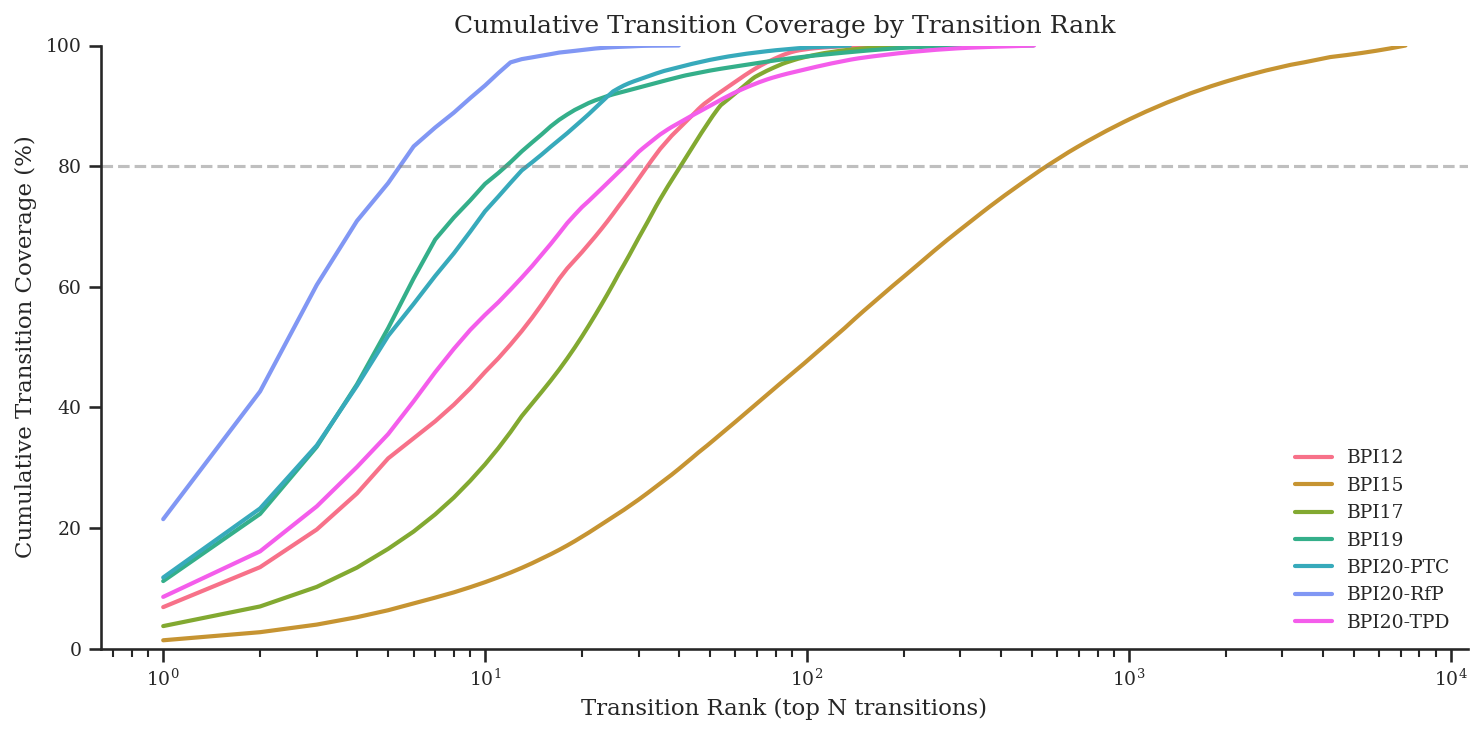

In [8]:
_apply_style()

colors = sns.color_palette("Set1", len(all_datasets))
fig, ax = plt.subplots(figsize=(10, 5))

for i, ds in enumerate(all_datasets):
    trans_df, _ = fetch_baseline_tables(ds, lifecycle=LIFECYCLE.get(ds, False))
    df_sorted = trans_df.sort_values("count", ascending=False).reset_index(drop=True)
    df_sorted["rank"] = df_sorted.index + 1
    df_sorted["cumulative_pct"] = df_sorted["count"].cumsum() / df_sorted["count"].sum() * 100
    ax.plot(df_sorted["rank"], df_sorted["cumulative_pct"], label=alias(ds), linewidth=2, color=colors[i])

ax.axhline(y=80, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Transition Rank (top N transitions)")
ax.set_ylabel("Cumulative Transition Coverage (%)")
ax.set_title("Cumulative Transition Coverage by Transition Rank")
ax.legend(frameon=False)
ax.set_xscale("log")
ax.set_ylim(0, 100)
fig.tight_layout()
plt.show()

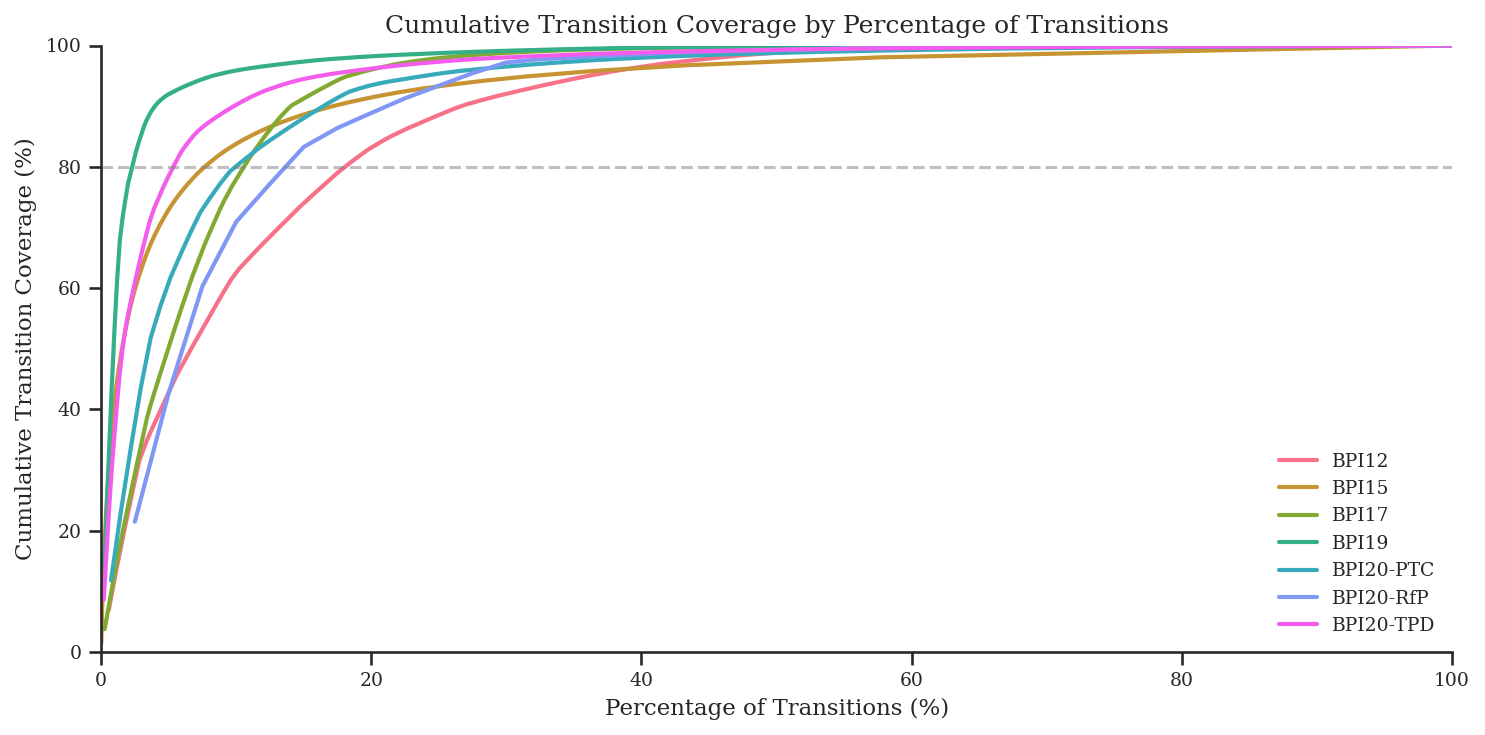

In [9]:
_apply_style()

colors = sns.color_palette("husl", len(all_datasets))
fig, ax = plt.subplots(figsize=(10, 5))

for i, ds in enumerate(all_datasets):
    trans_df, _ = fetch_baseline_tables(ds, lifecycle=LIFECYCLE.get(ds, False))
    df_sorted = trans_df.sort_values("count", ascending=False).reset_index(drop=True)
    df_sorted["rank"] = df_sorted.index + 1
    df_sorted["rank_pct"] = df_sorted["rank"] / len(df_sorted) * 100
    df_sorted["cumulative_pct"] = df_sorted["count"].cumsum() / df_sorted["count"].sum() * 100
    ax.plot(df_sorted["rank_pct"], df_sorted["cumulative_pct"], label=alias(ds), linewidth=2, color=colors[i])

ax.axhline(y=80, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Percentage of Transitions (%)")
ax.set_ylabel("Cumulative Transition Coverage (%)")
ax.set_title("Cumulative Transition Coverage by Percentage of Transitions")
ax.legend(frameon=False)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
fig.tight_layout()
plt.show()

## Per-Dataset Analysis

In [10]:
DATASET = "BPI15"

In [ ]:
transitions_df, _ = fetch_baseline_tables(DATASET, lifecycle=LIFECYCLE.get(DATASET, False))
row = baseline_latest[baseline_latest["log"] == DATASET].iloc[0]
self_count = transitions_df[transitions_df["current_activity"] == transitions_df["next_activity"]]["count"].sum()
total_count = transitions_df["count"].sum()

print(f"{alias(DATASET)}:  Acc={row['best_test_final_next_activity_acc']:.2%}  F1={row['best_test_final_next_activity_f1_macro']:.2%}  Self-transitions={self_count:,}/{total_count:,} ({self_count/total_count:.2%})")

df = transitions_df.sort_values("count", ascending=False).reset_index(drop=True)
df["cumulative_pct"] = df["count"].cumsum() / df["count"].sum() * 100

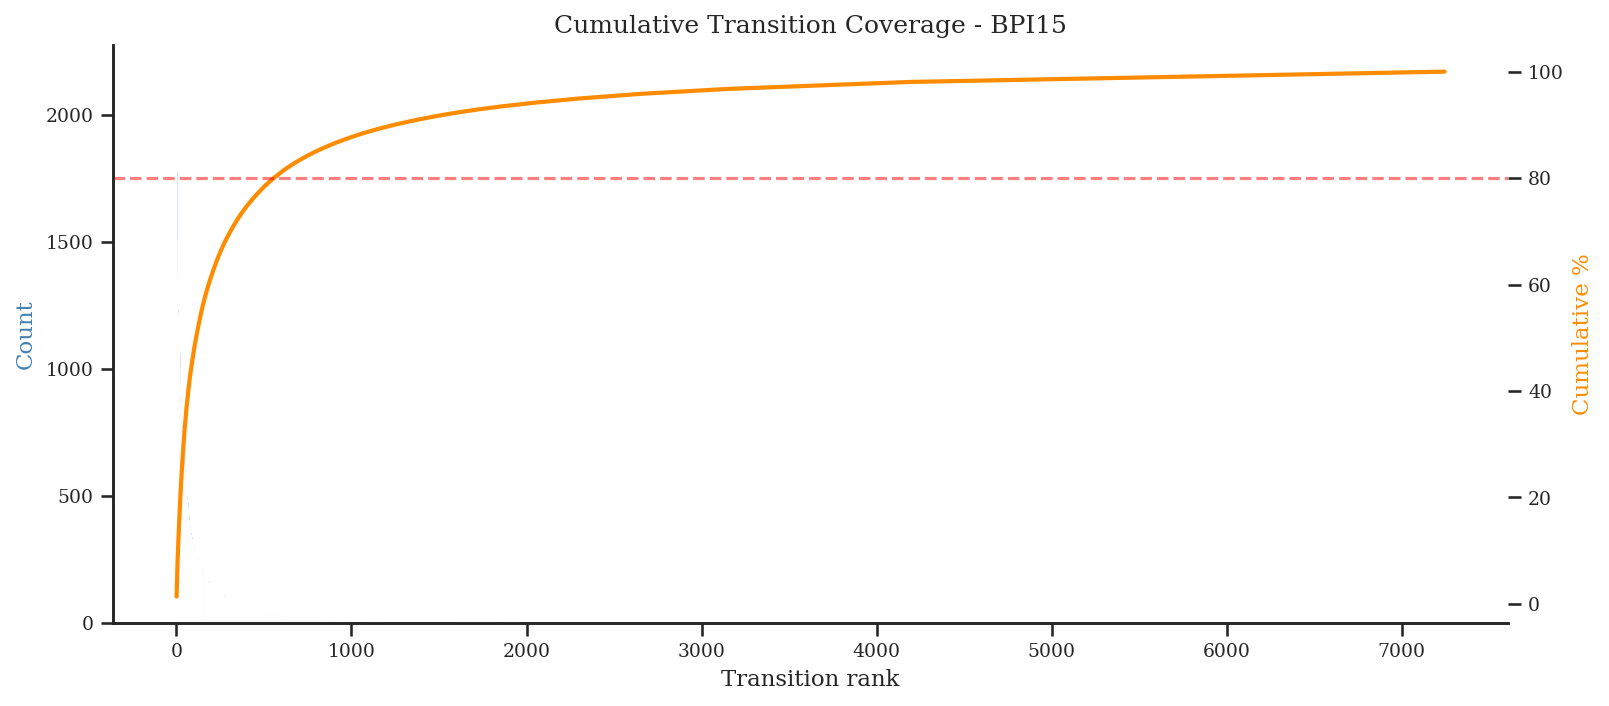

In [14]:
_apply_style()

df["rank"] = range(1, len(df) + 1)

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(df["rank"], df["count"], color="steelblue", alpha=0.7)
ax1.set_xlabel("Transition rank")
ax1.set_ylabel("Count", color="steelblue")

ax2 = ax1.twinx()
ax2.plot(df["rank"], df["cumulative_pct"], color="darkorange", linewidth=2)
ax2.set_ylabel("Cumulative %", color="darkorange")
ax2.axhline(y=80, color="red", linestyle="--", alpha=0.5)

plt.title(f"Cumulative Transition Coverage - {alias(DATASET)}")
plt.show()